Daniel De Chalons | Assignment 2
---
> The purpose of the following code is to analyse NHS appointment data. The data will be covered across 3 sections, with the bulk of the analytic conclusions in Section 3. The analysis of the data will cover the following questions:
<br>

§ Section 1 | **Sense Check and Initial Run-Through**<br>
- What is the number of locations, service settings, context types, national categories, and appointment statuses in the data sets?<br>
- What is the date range of the provided data sets, and which service settings reported the most appointments for a specific period?<br>
- What monthly and seasonal trends are evident, based on the number of appointments for service settings, context types, and national<br>   categories?

§ Section 2 | **A Tightened Focus on The Data**<br>
- What is the number of appointments and records per month? <br>
- What insights can be gained by looking at missed appointments?<br>
<br>

§ Section 3 | **Analytical Conclusions**<br>

- What are the most important patterns visible in the data relating to the use case?<br>
- What insights can be gained from the data, and what recommendations can be made to the NHS based on these insights?<br>
- Was there adequate staff and capacity in the networks?<br>
- What was the actual utilisation of resources?
<br>

---
> Section 1 | Sense Check and Initial Run-Through
--

In [37]:
# Import the necessary libraries.
import pandas as pd
import numpy as np

In [38]:
# Give a name to the dataframe that makes sense and is easy to refer back to.
duration = pd.read_csv('actual_duration.csv')

# Print the dataframe; viewing the first and last sections of the data for a sense-check.
print(duration.head())

print(duration.tail())

  sub_icb_location_code sub_icb_location_ons_code  \
0                   00L                 E38000130   
1                   00L                 E38000130   
2                   00L                 E38000130   
3                   00L                 E38000130   
4                   00L                 E38000130   

                        sub_icb_location_name icb_ons_code region_ons_code  \
0  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
1  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
2  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
3  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
4  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   

  appointment_date         actual_duration  count_of_appointments  
0        01-Dec-21           31-60 Minutes                    364  
1        01-Dec-21           21-30 Minutes                    619  
2       

In [39]:
# Check if there are any null values at all in the dataset as a broad search.
duration.isnull().values.any()

False

In [40]:
# Get a description of the data to better understand it.
print(duration.shape)

print(duration.dtypes)

(137793, 8)
sub_icb_location_code        object
sub_icb_location_ons_code    object
sub_icb_location_name        object
icb_ons_code                 object
region_ons_code              object
appointment_date             object
actual_duration              object
count_of_appointments         int64
dtype: object


In [41]:
# Further describe the data by getting the descriptive statistics.
duration.describe()

,count_of_appointments
count,137793.000000
mean,1219.080011
std,1546.902956
min,1.000000
25%,194.000000
50%,696.000000
75%,1621.000000
max,15400.000000


In [42]:
# Give a name to the dataframe that makes sense and is easy to refer back to.
regional = pd.read_csv('appointments_regional.csv')

# Print the dataframe; viewing the first and last sections of the data for a sense-check.
print(regional.head())

print(regional.tail())

  icb_ons_code appointment_month appointment_status hcp_type appointment_mode  \
0    E54000034           2020-01           Attended       GP     Face-to-Face   
1    E54000034           2020-01           Attended       GP     Face-to-Face   
2    E54000034           2020-01           Attended       GP     Face-to-Face   
3    E54000034           2020-01           Attended       GP     Face-to-Face   
4    E54000034           2020-01           Attended       GP     Face-to-Face   

  time_between_book_and_appointment  count_of_appointments  
0                             1 Day                   8107  
1                    15  to 21 Days                   6791  
2                       2 to 7 Days                  20686  
3                    22  to 28 Days                   4268  
4                     8  to 14 Days                  11971  
       icb_ons_code appointment_month appointment_status hcp_type  \
596816    E54000050           2022-06            Unknown  Unknown   
596817   

In [43]:
# Check if there are any null values at all in the dataset as a broad search.
regional.isnull().values.any()

False

In [44]:
# Get a description of the data to better understand it.
print(regional.shape)

print(regional.dtypes)

(596821, 7)
icb_ons_code                         object
appointment_month                    object
appointment_status                   object
hcp_type                             object
appointment_mode                     object
time_between_book_and_appointment    object
count_of_appointments                 int64
dtype: object


In [45]:
# Further describe the data by getting the descriptive statistics.
regional.describe()

,count_of_appointments
count,596821.000000
mean,1244.601857
std,5856.887042
min,1.000000
25%,7.000000
50%,47.000000
75%,308.000000
max,211265.000000


In [46]:
# Give a name to the dataframe that makes sense and is easy to refer back to.
categories = pd.read_excel('national_categories.xlsx')

# Print the dataframe; viewing the first and last sections of the data for a sense-check.
print(categories.head())

print(categories.tail())

  appointment_date icb_ons_code                       sub_icb_location_name  \
0       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
1       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
2       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
3       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
4       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   

        service_setting            context_type  \
0  Primary Care Network  Care Related Encounter   
1                 Other  Care Related Encounter   
2      General Practice  Care Related Encounter   
3      General Practice  Care Related Encounter   
4      General Practice  Care Related Encounter   

                        national_category  count_of_appointments  \
0  Patient contact during Care Home Round                      3   
1                         Planned Clinics                      7   
2             

In [47]:
# Check if there are any null values at all in the dataset as a broad search.
categories.isnull().values.any()

False

In [48]:
# Get a description of the data to better understand it.
print(categories.shape)

print(categories.dtypes)

(817394, 8)
appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month                object
dtype: object


In [49]:
# Further describe the data by getting the descriptive statistics.
categories.describe()

,appointment_date,count_of_appointments
count,817394,817394.000000
mean,2022-01-16 00:50:35.860796160,362.183684
min,2021-08-01 00:00:00,1.000000
25%,2021-10-25 00:00:00,7.000000
50%,2022-01-18 00:00:00,25.000000
75%,2022-04-07 00:00:00,128.000000
max,2022-06-30 00:00:00,16590.000000
std,NaN,1084.576600


> **Question 1.**

What is the number of locations, service settings, context types, national categories, and appointment statuses in the data sets?

In [50]:
# No. of Locations. Determine this by running a unique count on the sub-icb location name column.
print(categories['sub_icb_location_name'].nunique())

106


In [51]:
# No. of service settings.

settings_number_count = categories['service_setting'].nunique()

settings_number_count

5

In [52]:
# No. of context types.
print(categories['context_type'].nunique())

3


In [53]:
# No. of national categories.
print(categories['national_category'].nunique())

18


In [54]:
# No. of appointment statuses.
print(regional['appointment_status'].nunique())

3


> **Question 2 & 3.**

| *What is the date range of the provided data sets, and which service settings reported the most appointments for a specific period?*

| *What monthly and seasonal trends are evident, based on the number of appointments for service settings, context types, and national          categories?*

In [55]:
# First convert the date column to the proper format so that it reads properly. 
# Specifying the format stops the potential error for individual parsing of dates.
duration['appointment_date'] = pd.to_datetime(duration['appointment_date'], format = '%d-%b-%y')

# Next set.
regional['appointment_month'] = pd.to_datetime(regional['appointment_month'], format = '%Y-%m')

# Next set.
categories['appointment_date'] = pd.to_datetime(categories['appointment_date'], format = '%d-%m-%Y')

# Set the variables for the earliest and latest dates for all the data sets.
duration_min_date = duration['appointment_date'].min()
duration_max_date = duration['appointment_date'].max()

# Next set.
regional_min_date = regional['appointment_month'].min()
regional_max_date = regional['appointment_month'].max()

# Next set.
categories_min_date = categories['appointment_date'].min()
categories_max_date = categories['appointment_date'].max()

# Print the variables with text in a digestible way.
print('In the Actual Duration file:\nThe earliest date is: ', duration_min_date)
print('The latest date is: ', duration_max_date)
print('\nIn the appointments regional file:\nThe earliest date is: ', regional_min_date)
print('The latest date is: ', regional_max_date)
print('\nIn the National Categories file:\nThe earliest date is: ', categories_min_date)
print('The latest date is: ', categories_max_date)

In the Actual Duration file:
The earliest date is:  2021-12-01 00:00:00
The latest date is:  2022-06-30 00:00:00

In the appointments regional file:
The earliest date is:  2020-01-01 00:00:00
The latest date is:  2022-06-01 00:00:00

In the National Categories file:
The earliest date is:  2021-08-01 00:00:00
The latest date is:  2022-06-30 00:00:00


> So far, we can see that the overall date range across the data sets is from the 1st of January 2020, to June 30th 2022.

Now, let's look at the number of appointments for each of the **service settings** in our given period.


In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by service setting and month then sum the appointment count.
monthly_counts = categories.groupby(['service_setting', 'appointment_month'])['count_of_appointments'].sum().reset_index()

# Sort the values so that the values show by service setting and from high to low.
monthly_counts = monthly_counts.sort_values(by = ['service_setting', 'count_of_appointments'], ascending = [True, False])

# Aid readability by formatting with commas.
formatted_monthly_count = monthly_counts.style.format({'count_of_appointments': '{:,}'})

formatted_monthly_count

,service_setting,appointment_month,count_of_appointments
7,Extended Access Provision,2022-03,"231,905"
9,Extended Access Provision,2022-05,"220,511"
10,Extended Access Provision,2022-06,"209,652"
2,Extended Access Provision,2021-10,"209,539"
3,Extended Access Provision,2021-11,"207,577"
6,Extended Access Provision,2022-02,"196,627"
8,Extended Access Provision,2022-04,"192,284"
1,Extended Access Provision,2021-09,"187,906"
5,Extended Access Provision,2022-01,"186,375"
4,Extended Access Provision,2021-12,"173,504"


So, the service setting that reported the most appointments for **all** periods was overwhelmingly the 'General Practice' setting. Now, let's take a look at this data on a graph.

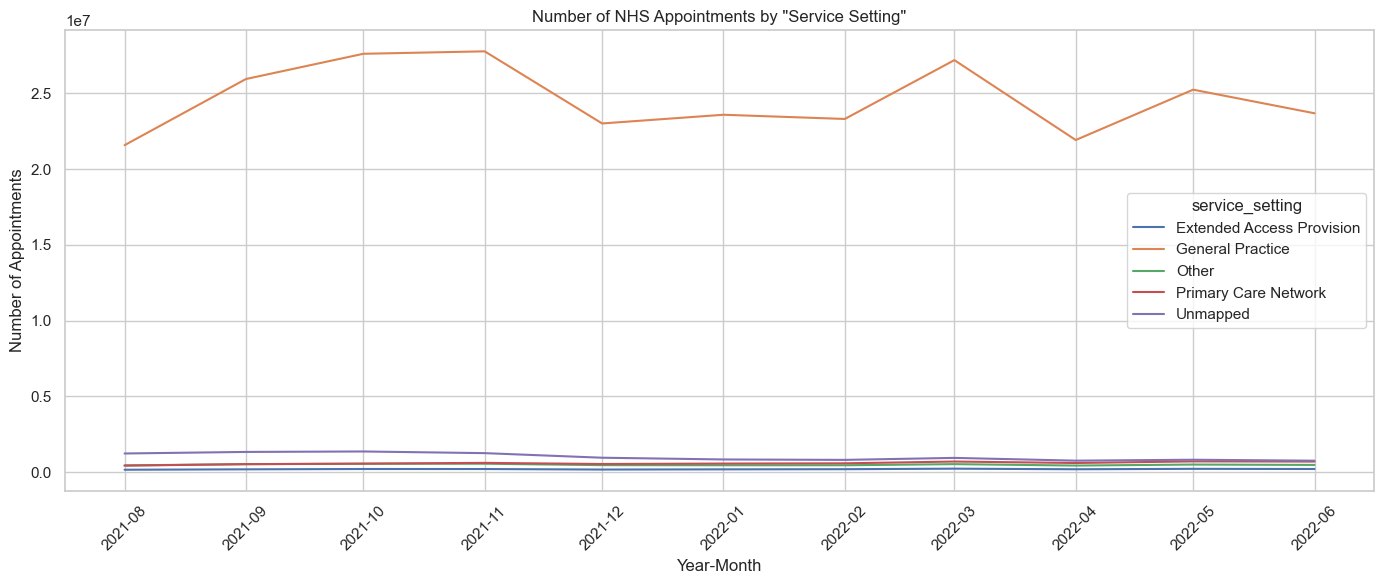

In [57]:
# Make sure that appointment_month is in datetime format.
monthly_counts['appointment_month'] = pd.to_datetime(monthly_counts['appointment_month'], format='%Y-%m')

# Set the plot style.
sns.set(style = 'whitegrid')

# Create the line plot.
plt.figure(figsize = (14, 6))
sns.lineplot(
    data = monthly_counts,
    x = 'appointment_month',
    y = 'count_of_appointments',
    hue = 'service_setting')

# Format and Label.
plt.title('Number of NHS Appointments by "Service Setting"')
plt.xlabel('Year-Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

>The 'General Practice' service setting overshadows the rest of the values, and so below I have filtered out 'General Practice' for a closer look at those values overshadowed.

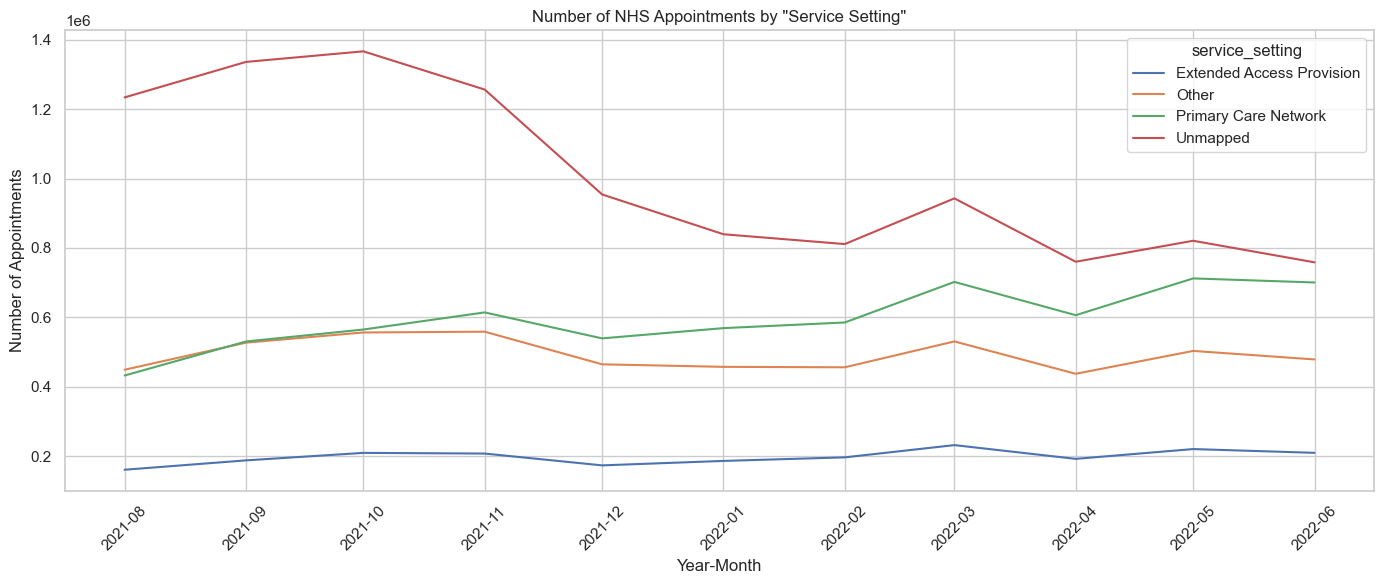

In [58]:
# Make sure that appointment_month is in datetime format.
monthly_counts['appointment_month'] = pd.to_datetime(monthly_counts['appointment_month'], format='%Y-%m')

# Filter out the General Practice value to take a closer look at the other values.
monthly_counts_nogp = monthly_counts[monthly_counts['service_setting'] != 'General Practice']

# Set the plot style.
sns.set(style = 'whitegrid')

# Create the line plot.
plt.figure(figsize = (14, 6))
sns.lineplot(
    data = monthly_counts_nogp,
    x = 'appointment_month',
    y = 'count_of_appointments',
    hue = 'service_setting')

# Format and Label.
plt.title('Number of NHS Appointments by "Service Setting"')
plt.xlabel('Year-Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

> So, what does this data show us in terms of monthly and seasonal trends?

In terms of monthly trends something which is immediately clear is the consistent spike of appointments in March, across all of the service settings. 

The appointments also see higher numbers when the months begin to get colder from September (Autumn), the gentle dip in December might be exaplained by people going away for holiday or staying inside longer and not socially interacting, especially within the context of a world in the immediate aftermath of the COVID pandemic, this makes sense.

> *Now, let's look at the number of appointments for each of the **context types** in our given period.

In [59]:
# Group by service setting and month then sum the appointment count.
monthly_counts = categories.groupby(['context_type', 'appointment_month'])['count_of_appointments'].sum().reset_index()

# Sort the values so that the values show by context_type and from high to low.
monthly_counts = monthly_counts.sort_values(by = ['context_type', 'count_of_appointments'], ascending = [True, False])

# Aid readability by formatting with commas.
formatted_monthly_count = monthly_counts.style.format({'count_of_appointments': '{:,}'})

formatted_monthly_count

,context_type,appointment_month,count_of_appointments
3,Care Related Encounter,2021-11,"26,282,778"
2,Care Related Encounter,2021-10,"26,125,201"
7,Care Related Encounter,2022-03,"25,928,850"
1,Care Related Encounter,2021-09,"24,404,251"
9,Care Related Encounter,2022-05,"24,101,243"
10,Care Related Encounter,2022-06,"22,621,827"
5,Care Related Encounter,2022-01,"22,441,947"
6,Care Related Encounter,2022-02,"22,211,021"
4,Care Related Encounter,2021-12,"21,798,612"
8,Care Related Encounter,2022-04,"20,904,193"


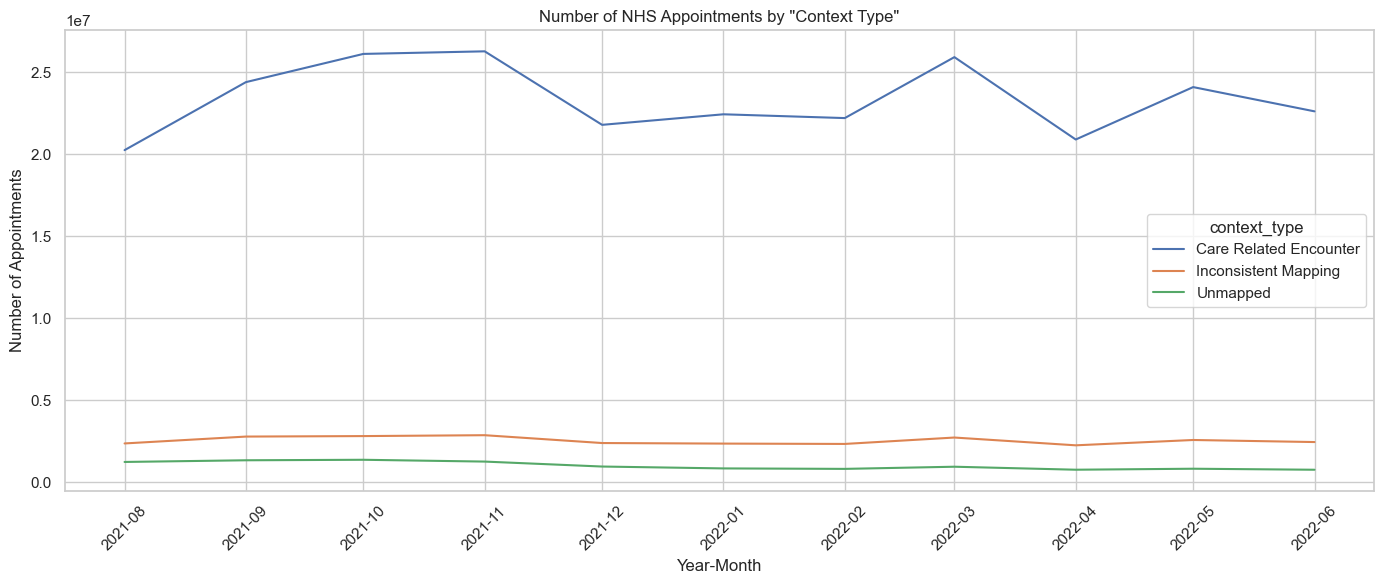

In [60]:
monthly_counts['appointment_month'] = pd.to_datetime(monthly_counts['appointment_month'], format='%Y-%m')

# Set the plot style.
sns.set(style = 'whitegrid')

# Create the line plot.
plt.figure(figsize = (14, 6))
sns.lineplot(
    data = monthly_counts,
    x = 'appointment_month',
    y = 'count_of_appointments',
    hue = 'context_type')

# Format and Label.
plt.title('Number of NHS Appointments by "Context Type"')
plt.xlabel('Year-Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

> Now, let's look at the number of appointments for each of the **national categories** in our given period.

In [61]:
# Group by service setting and month then sum the appointment count.
monthly_counts = categories.groupby(['national_category', 'appointment_month'])['count_of_appointments'].sum().reset_index()

# Sort the values so that the values show by context_type and from high to low.
monthly_counts = monthly_counts.sort_values(by = ['national_category', 'count_of_appointments'], ascending = [True, False])

# Aid readability by formatting with commas.
formatted_monthly_count = monthly_counts.style.format({'count_of_appointments': '{:,}'})

formatted_monthly_count

,national_category,appointment_month,count_of_appointments
7,Care Home Needs Assessment & Personalised Care and Support Planning,2022-03,"43,189"
9,Care Home Needs Assessment & Personalised Care and Support Planning,2022-05,"42,904"
10,Care Home Needs Assessment & Personalised Care and Support Planning,2022-06,"40,222"
3,Care Home Needs Assessment & Personalised Care and Support Planning,2021-11,"38,827"
5,Care Home Needs Assessment & Personalised Care and Support Planning,2022-01,"37,988"
6,Care Home Needs Assessment & Personalised Care and Support Planning,2022-02,"37,219"
8,Care Home Needs Assessment & Personalised Care and Support Planning,2022-04,"35,282"
4,Care Home Needs Assessment & Personalised Care and Support Planning,2021-12,"34,653"
1,Care Home Needs Assessment & Personalised Care and Support Planning,2021-09,"33,503"
2,Care Home Needs Assessment & Personalised Care and Support Planning,2021-10,"32,441"


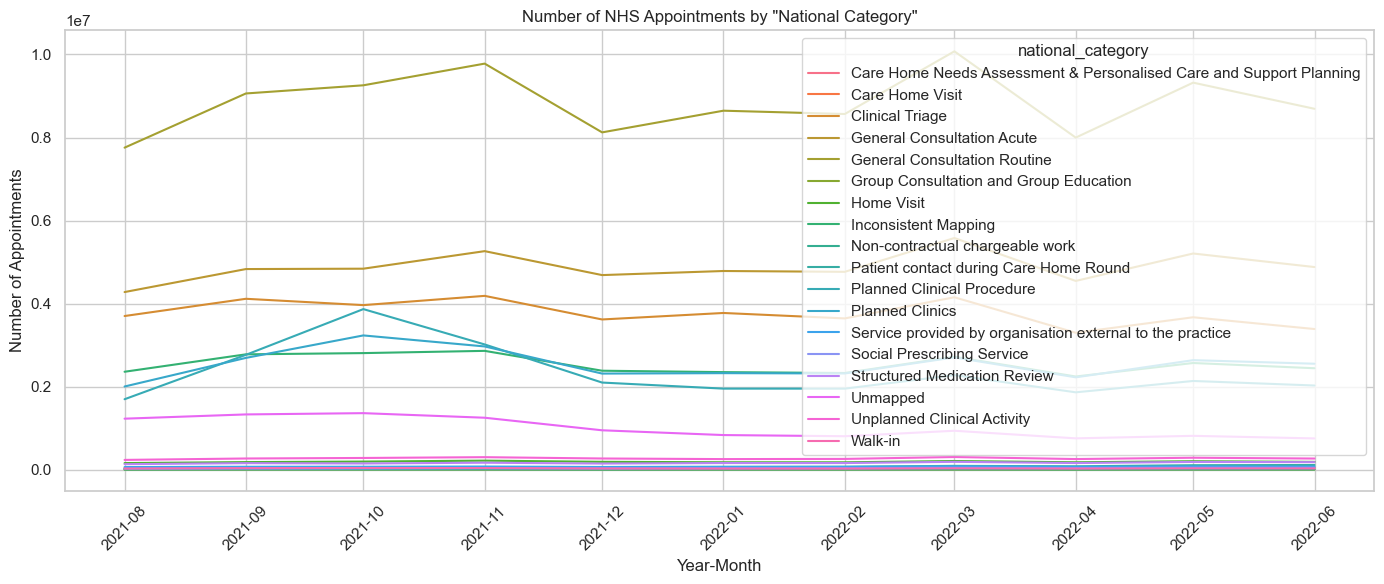

In [62]:
monthly_counts['appointment_month'] = pd.to_datetime(monthly_counts['appointment_month'], format='%Y-%m')

# Set the plot style.
sns.set(style = 'whitegrid')

# Create the line plot.
plt.figure(figsize = (14, 6))
sns.lineplot(
    data = monthly_counts,
    x = 'appointment_month',
    y = 'count_of_appointments',
    hue = 'national_category')

# Format and Label.
plt.title('Number of NHS Appointments by "National Category"')
plt.xlabel('Year-Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

---
>Section 2
>--

>What is the number of appointments and records per month?

In [63]:
duration['appointment_date'] = duration['appointment_date'].dt.to_period('M')

monthly_count = duration.groupby('appointment_date')['count_of_appointments'].sum().reset_index()

# Sort the values so that the values show by service setting and from high to low.
monthly_count = monthly_count.sort_values(by = ['count_of_appointments'], ascending = [False])

# Aid readability by formatting with commas.
formatted_monthly_count = monthly_count.style.format({'count_of_appointments': '{:,}'})

formatted_monthly_count

# Months_in_set_check = duration['appointment_date'].nunique()

# Months_in_set_check

,appointment_date,count_of_appointments
3,2022-03,"27,170,002"
5,2022-05,"25,343,941"
6,2022-06,"23,715,317"
1,2022-01,"23,597,196"
2,2022-02,"23,351,939"
0,2021-12,"22,853,483"
4,2022-04,"21,948,814"


In [64]:
# Make sure to pass a name to the reset_index() in that bracket, to be able to format. (Name the column)
records_per_month = (duration.groupby('appointment_date').size().reset_index(name = 'number_of_records'))

formatted_records_per_month = records_per_month.style.format({'number_of_records': '{:,}'})

formatted_records_per_month

,appointment_date,number_of_records
0,2021-12,"19,507"
1,2022-01,"19,643"
2,2022-02,"18,974"
3,2022-03,"21,236"
4,2022-04,"19,078"
5,2022-05,"20,128"
6,2022-06,"19,227"


In [65]:
regional['appointment_month'] = regional['appointment_month'].dt.to_period('M')

monthly_count = regional.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Sort the values so that the values show by service setting and from high to low.
monthly_count = monthly_count.sort_values(by = ['count_of_appointments'], ascending = [False])

# Aid readability by formatting with commas.
formatted_monthly_count = monthly_count.style.format({'count_of_appointments': '{:,}'})

formatted_monthly_count

# --Ignore-- Months_in_set_check = regional['appointment_month'].nunique()

# --Ignore-- Months_in_set_check

,appointment_month,count_of_appointments
22,2021-11,"30,405,070"
21,2021-10,"30,303,834"
26,2022-03,"29,595,038"
20,2021-09,"28,522,501"
9,2020-10,"28,301,932"
28,2022-05,"27,495,508"
14,2021-03,"27,225,424"
0,2020-01,"27,199,296"
17,2021-06,"26,784,182"
8,2020-09,"26,714,255"


In [66]:
# Make sure to pass a name to the reset_index() in that bracket, to be able to format. (Name the column)
records_per_month = (regional.groupby('appointment_month').size().reset_index(name = 'number_of_records'))

formatted_records_per_month = records_per_month.style.format({'number_of_records': '{:,}'})

formatted_records_per_month

,appointment_month,number_of_records
0,2020-01,"20,889"
1,2020-02,"20,689"
2,2020-03,"21,350"
3,2020-04,"19,124"
4,2020-05,"18,338"
5,2020-06,"18,844"
6,2020-07,"19,502"
7,2020-08,"19,247"
8,2020-09,"20,043"
9,2020-10,"20,122"


In [67]:
monthly_count = categories.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Sort the values so that the values show by service setting and from high to low.
monthly_count = monthly_count.sort_values(by = ['count_of_appointments'], ascending = [False])

# Aid readability by formatting with commas.
formatted_monthly_count = monthly_count.style.format({'count_of_appointments': '{:,}'})

formatted_monthly_count

,appointment_month,count_of_appointments
3,2021-11,"30,405,070"
2,2021-10,"30,303,834"
7,2022-03,"29,595,038"
1,2021-09,"28,522,501"
9,2022-05,"27,495,508"
10,2022-06,"25,828,078"
5,2022-01,"25,635,474"
6,2022-02,"25,355,260"
4,2021-12,"25,140,776"
8,2022-04,"23,913,060"


In [68]:
# Make sure to pass a name to the reset_index() in that bracket, to be able to format. (Name the column)
records_per_month = (categories.groupby('appointment_month').size().reset_index(name = 'number_of_records'))

formatted_records_per_month = records_per_month.style.format({'number_of_records': '{:,}'})

formatted_records_per_month

,appointment_month,number_of_records
0,2021-08,"69,999"
1,2021-09,"74,922"
2,2021-10,"74,078"
3,2021-11,"77,652"
4,2021-12,"72,651"
5,2022-01,"71,896"
6,2022-02,"71,769"
7,2022-03,"82,822"
8,2022-04,"70,012"
9,2022-05,"77,425"


---
>Now, we will look at the missed appointments

In [69]:
# A count of records for each attendance value.
attendance_status_count = (regional.groupby('appointment_status').size().reset_index(name = 'number_of_respective'))

formatted_attendance_status_count = attendance_status_count.style.format({'number_of_respective': '{:,}'})

formatted_attendance_status_count

,appointment_status,number_of_respective
0,Attended,"232,137"
1,DNA,"163,360"
2,Unknown,"201,324"


In [70]:
# Group by appointment_status and month then sum the appointment count.
monthly_counts = regional.groupby(['appointment_status', 'appointment_month'])['count_of_appointments'].sum().reset_index()

# Sort the values so that the values show by service setting and from high to low.
monthly_counts = monthly_counts.sort_values(by = ['appointment_status', 'appointment_month'], ascending = [True, False])

# Aid readability by formatting with commas.
formatted_monthly_count = monthly_counts.style.format({'count_of_appointments': '{:,}'})

formatted_monthly_count

,appointment_status,appointment_month,count_of_appointments
29,Attended,2022-06,"23,715,317"
28,Attended,2022-05,"25,343,941"
27,Attended,2022-04,"21,948,814"
26,Attended,2022-03,"27,170,002"
25,Attended,2022-02,"23,351,939"
24,Attended,2022-01,"23,597,196"
23,Attended,2021-12,"22,853,483"
22,Attended,2021-11,"27,667,665"
21,Attended,2021-10,"27,170,506"
20,Attended,2021-09,"25,757,066"


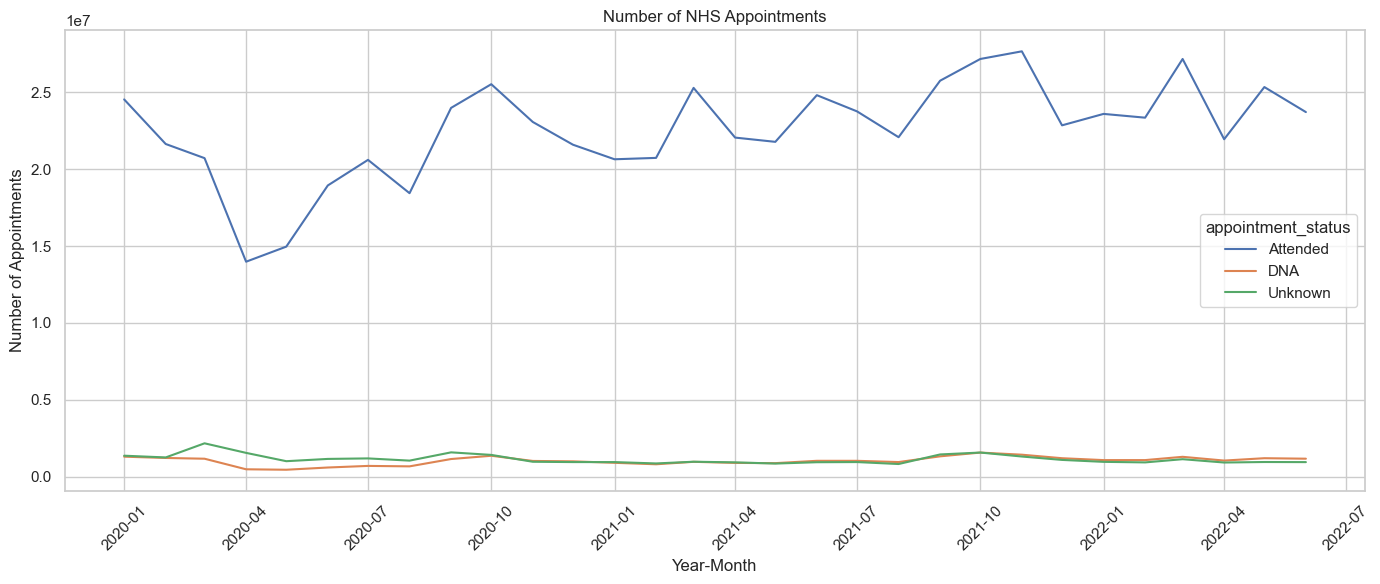

In [72]:
# Make sure that appointment_month is in datetime format.
# Convert to a string first to avoid potential error.
monthly_counts['appointment_month'] = monthly_counts['appointment_month'].astype(str)
monthly_counts['appointment_month'] = pd.to_datetime(monthly_counts['appointment_month'], format='%Y-%m')

# Set the plot style.
sns.set(style = 'whitegrid')

# Create the line plot.
plt.figure(figsize = (14, 6))
sns.lineplot(
    data = monthly_counts,
    x = 'appointment_month',
    y = 'count_of_appointments',
    hue = 'appointment_status'
)

# Format and Label.
plt.title('Number of NHS Appointments')
plt.xlabel('Year-Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

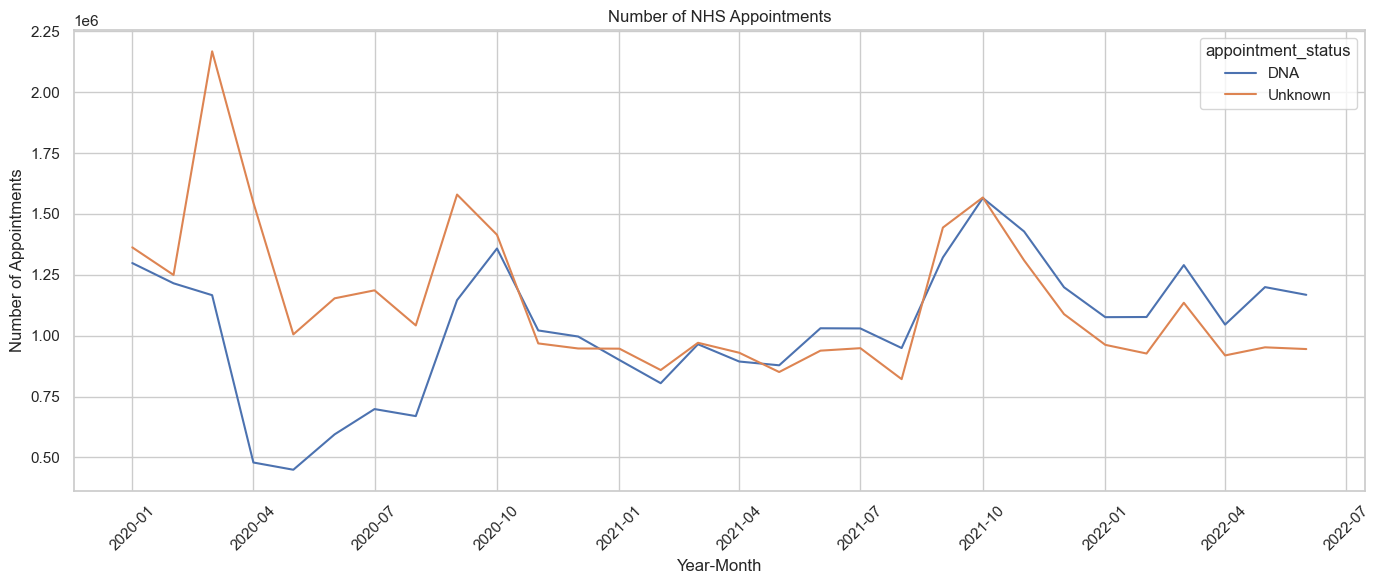

In [73]:
# Make sure that appointment_month is in datetime format.
monthly_counts['appointment_month'] = pd.to_datetime(monthly_counts['appointment_month'], format='%Y-%m')

# Set the plot style.
sns.set(style = 'whitegrid')

monthly_counts_noattend = monthly_counts[monthly_counts['appointment_status'] != 'Attended']

# Create the line plot.
plt.figure(figsize = (14, 6))
sns.lineplot(
    data = monthly_counts_noattend,
    x = 'appointment_month',
    y = 'count_of_appointments',
    hue = 'appointment_status')

# Format and Label.
plt.title('Number of NHS Appointments')
plt.xlabel('Year-Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

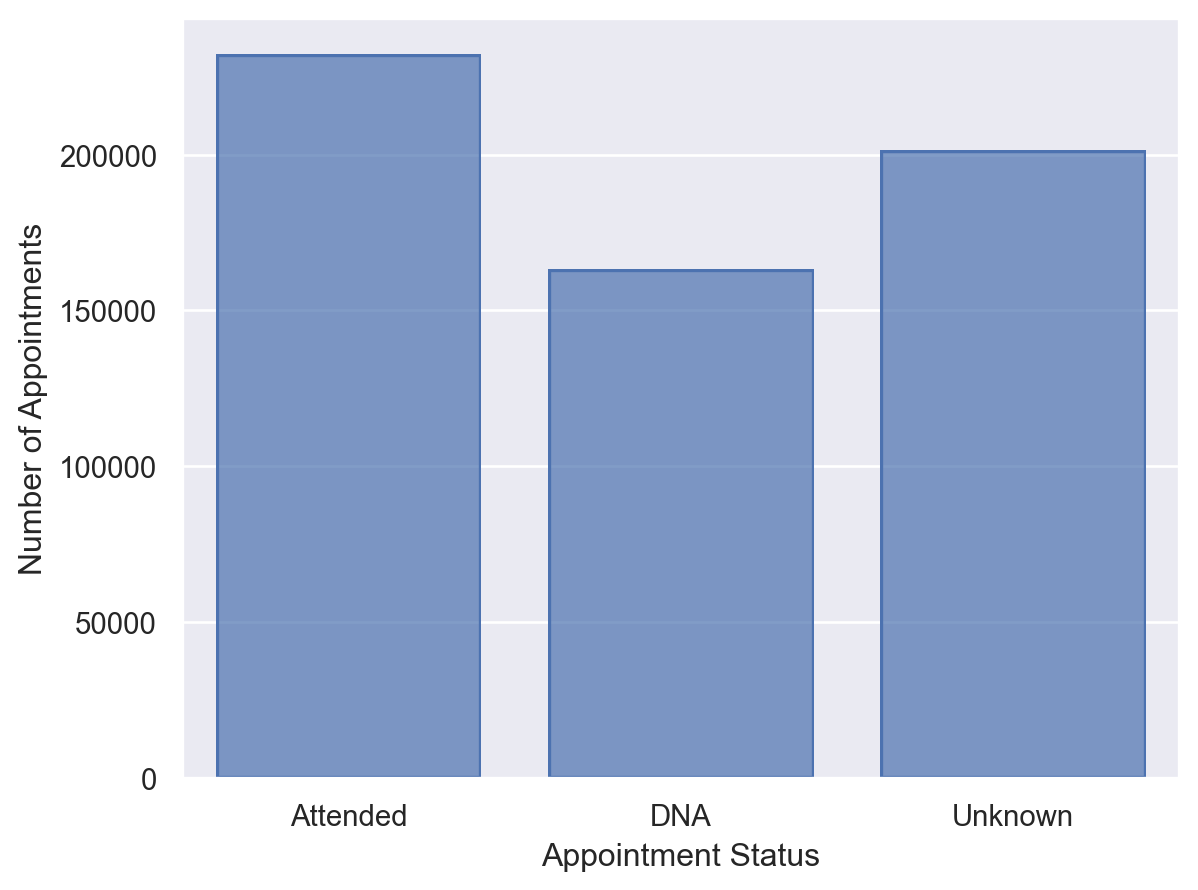

In [74]:
# Import seaborn.objects as so.

import seaborn.objects as so

graph = so.Plot(attendance_status_count, x = "appointment_status", y = "number_of_respective").add(so.Bar(),so.Dodge())

graph.label(x = "Appointment Status", y = "Number of Appointments")

>So, What insights can be gained by looking at missed appointments?

Post-pandemic 'attended' numbers are fairly stable in number, and so resource assignment could be be planned from the numbers, but it would also be benefical to have an intimate look in a few years time, to see what patient behaviour looks like in the post COVID-19 world, and what patterns emerge over time there, whether or not things return to the 2019-and-before 'normal'. 

We can also see that there is still a significant count of 'unknown' appointment statuses. We might draw from this that some practices data literacy, perhaps how seriously/well they use their given systems, varies. This could be remedied by increasing the standardisation of systems and system training. 

**§ Section 3 | Analytical Conclusions**

- What are the most important patterns visible in the data relating to the use case?
- What insights can be gained from the data, and what recommendations can be made to the NHS based on these insights?
- Was there adequate staff and capacity in the networks?
- What was the actual utilisation of resources?

One of the first and most obvious patterns in the data is the spike in the number of appointments across all categories in March. If we look at an estimate of the GP appointments over the year 2021-2022 from the NHS, we can see that the prediction for March is actually a downturn in appointments. A report by the The Healthcare Financial Management Association states “…Unspent allocation…cannot be carried forward to the next financial year”, so, what could be drawn from this is that the estimate may reflect actual demand, but not real appointment distribution (GP referral), where practises are referring more patients in an attempt to make budget by year end. 

The highest actual utilisation of resource (in no. of appointments) for one month was 30,405,070 in November 2021. Given that the NHS has on average a capacity of 1.2m appointments per day, November would have capacity of 36m and therefore, would not have exceeded capacity. Taken alone, this does show that there is sufficient staffing level, but a closer per location, and each location's respective capacities, look, would certainly give a much clearer picture of the actual staffing level vs demand. 

A more intimate look at the actual happenings within each practice would also serve to improve clarity around whether there was adequate staffing and capacity. For example, visualising waiting times across the day — pinpointing when and where these tend to peak, and identifying patterns of congestion as they emerge would give staff a greater ability to respond to increased demand. This level of insight would allow time and resources to be allocated where and when they are most needed, helping to prevent bottlenecks before they form, reduce patient frustration, and ultimately improve the overall flow and quality of service.